In [33]:
!pip install "stable-baselines3[extra]"

   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---- ----------------------------------- 0.4/3.5 MB 8.3 MB/s eta 0:00:01
   ---------- ----------------------------- 0.9/3.5 MB 9.3 MB/s eta 0:00:01
   --------------- ------------------------ 1.4/3.5 MB 9.5 MB/s eta 0:00:01
   --------------------- ------------------ 1.8/3.5 MB 9.7 MB/s eta 0:00:01
   -------------------------- ------------- 2.3/3.5 MB 9.7 MB/s eta 0:00:01
   ------------------------------- -------- 2.8/3.5 MB 9.8 MB/s eta 0:00:01
   ------------------------------------- -- 3.2/3.5 MB 9.8 MB/s eta 0:00:01
   ---------------------------------------- 3.5/3.5 MB 9.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   -- ------------------------------------- 0.4/5.5 MB 7.6 MB/s eta 0:00:01
   ------ --------------------------------- 0.8/5.5 MB 8.9 MB/s eta 0:00:01
   --------- ------------------------------ 1.3/5.5 MB 10.4 MB/s eta 0:00:01
   ------------ ---------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from mazelib import Maze
from mazelib.generate.BacktrackingGenerator import BacktrackingGenerator
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import pdb
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

In [24]:
import numpy as np

try:
    import gymnasium as gym
    from gymnasium import spaces
except ImportError:
    import gym
    from gym import spaces

from mazelib import Maze
from mazelib.generate.BacktrackingGenerator import BacktrackingGenerator

ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}

class MazeGymEnv(gym.Env):
    def __init__(self, cells_h: int, cells_w: int, max_steps: int = 350):
        super().__init__()
        self.cells_h = int(cells_h)
        self.cells_w = int(cells_w)
        self.max_steps = int(max_steps)

        self.action_space = spaces.Discrete(4)

        # ✅ shape 확정을 위해 dummy maze 1회 생성
        dummy_seed = 0
        grid, start, goal = self._make_maze(dummy_seed)
        self.h, self.w = grid.shape

        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(3, self.h, self.w), dtype=np.float32
        )

        # 실제 상태는 reset에서 seed로 다시 생성
        self.grid = None
        self.start = None
        self.goal = None
        self._pos = None
        self._steps = 0

    def render(self):
        # 벽=검정, 빈칸=흰색, agent=빨강, goal=초록
        img = np.ones((self.h, self.w, 3), dtype=np.uint8) * 255
    
        # 벽
        img[self.grid == 1] = [0, 0, 0]
    
        # goal
        gr, gc = self.goal
        img[gr, gc] = [0, 255, 0]
    
        # agent
        r, c = self._pos
        img[r, c] = [255, 0, 0]
    
        return img

    def _make_maze(self, seed: int):
        np.random.seed(seed)
        maze = Maze(seed=seed)
        maze.generator = BacktrackingGenerator(self.cells_h, self.cells_w)
        maze.generate()

        grid = np.array(maze.grid, dtype=np.int8)
        start = (1, 1)
        goal = (grid.shape[0] - 2, grid.shape[1] - 2)
        grid[start] = 0
        grid[goal] = 0
        return grid.astype(np.float32), start, goal

    def _build_obs(self):
        obs = np.zeros((3, self.h, self.w), dtype=np.float32)
        obs[0] = self.grid
        r, c = self._pos
        obs[1, r, c] = 1.0
        gr, gc = self.goal
        obs[2, gr, gc] = 1.0
        return obs

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is None:
            seed = int(self.np_random.integers(0, 2**31 - 1))

        self.grid, self.start, self.goal = self._make_maze(seed)
        self._pos = self.start
        self._steps = 0
        return self._build_obs(), {"seed": seed, "start": self.start, "goal": self.goal}

    def step(self, action):
        dr, dc = ACTIONS[int(action)]
        r, c = self._pos
        nr, nc = r + dr, c + dc

        # open cell = 0
        if 0 <= nr < self.h and 0 <= nc < self.w and self.grid[nr, nc] == 0.0:
            self._pos = (int(nr), int(nc))

        self._steps += 1
        terminated = (self._pos == self.goal)
        truncated = (self._steps >= self.max_steps)
        reward = 1.0 if terminated else 0.0

        return self._build_obs(), reward, terminated, truncated, {}

In [19]:
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class MazeCNN(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim: int=128):
        super().__init__(observation_space, features_dim)

        n_input_channels = observation_space.shape[0]

        self.cnn = nn.Sequential(
            nn.Conv2d(n_input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )

        with torch.no_grad():
            sample = torch.as_tensor(observation_space.sample()[None]).float()
            n_flatten = self.cnn(sample).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, features_dim),
            nn.ReLU(),
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        return self.linear(self.cnn(observations))

In [32]:
cells_h, cells_w = 3, 3
max_steps = 350

def make_env():
    return MazeGymEnv(cells_h=cells_h, cells_w=cells_w, max_steps=max_steps)

vec_env = make_vec_env(make_env, n_envs=8, seed=0)

policy_kwargs = dict(
    features_extractor_class = MazeCNN,
    features_extractor_kwargs=dict(features_dim=128),
    normalize_images=False
)

model = PPO(
    policy="CnnPolicy",
    env=vec_env,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    policy_kwargs=policy_kwargs,
    verbose=1,
    device="auto",
    tensorboard_log = "./ppo_maze_tensorboard/"
)

model.learn(total_timesteps=200_000)
model.save("ppo_maze_seeded_cnn")

Using cpu device


ImportError: Trying to log data to tensorboard but tensorboard is not installed.

In [27]:
import imageio
import numpy as np

def record_gif(env, model, filename="maze.gif", seed=1, max_steps=200):
    frames = []

    obs, _ = env.reset(seed=seed)
    frames.append(env.render())

    for _ in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)

        frames.append(env.render())

        if terminated or truncated:
            break

    imageio.mimsave(filename, frames, fps=5)
    print(f"Saved GIF to {filename}")

In [28]:
env = MazeGymEnv(cells_h=3, cells_w=3, max_steps=350)

record_gif(env, model, filename="maze_solution.gif", seed=1)

Saved GIF to maze_solution.gif


In [30]:
env = MazeGymEnv(cells_h=3, cells_w=3, max_steps=350)

record_gif(env, model, filename="maze_solution2.gif", seed=2)

Saved GIF to maze_solution2.gif


In [31]:
env = MazeGymEnv(cells_h=3, cells_w=3, max_steps=350)

record_gif(env, model, filename="maze_solution3.gif", seed=3)

Saved GIF to maze_solution3.gif


# PPO 직접 구현

In [6]:
class MLPPolicyValue(nn.Module):
    def __init__(self, H: int, W: int, in_channels: int=3, hidden: int=512):
        super().__init__()
        self.H = H
        self.W = W
        self.in_channels = in_channels

        obs_dim = in_channels * H * W

        self.fc1 = nn.Linear(obs_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)

        self.pi = nn.Linear(hidden, 4)
        self.v = nn.Linear(hidden, 1)

        nn.init.orthogonal_(self.fc1.weight, gain=1.0)
        nn.init.orthogonal_(self.fc2.weight, gain=1.0)
        nn.init.orthogonal_(self.pi.weight, gain=0.01)
        nn.init.orthogonal_(self.v.weight, gain=1.0)

        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)
        nn.init.zeros_(self.pi.bias)
        nn.init.zeros_(self.v.bias)

    def forward(self, obs: torch.Tensor):
        B = obs.shape[0]
        x = obs.view(B, -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        logits = self.pi(x) # (B, 4)
        value = self.v(x).squeeze(-1) # (B,)
        return logits, value        

In [7]:
def build_obs(grid: torch.Tensor, agent_rc: tuple[int, int], goal_rc: tuple[int, int]):
    """
    grid: (H, W) int/bool/float
    return obs: (3, H, W) float 32
    """
    H, W = grid.shape
    wall = grid.float()

    agent = torch.zeros((H, W), dtype=torch.float32)
    goal = torch.zeros((H, W), dtype=torch.float32)
    ar, ac = agent_rc
    gr, gc = goal_rc
    agent[ar, ac] = 1.0
    goal[gr, gc] = 1.0

    obs = torch.stack([wall, agent, goal], dim=0)
    return obs

In [8]:
class RolloutBuffer:
    def __init__(self):
        self.buffer = list()

    def store(self, transition):
        self.buffer.append(transition)

    def sample(self):
        states, actions, rewards, next_states, dones = map(np.array, zip(*self.buffer))
        self.buffer.clear()
        return (
            torch.FloatTensor(states),
            torch.FloatTensor(actions),
            torch.FloatTensor(rewards).unsqueeze(1),
            torch.FloatTensor(next_states),
            torch.FloatTensor(dones).unsqueeze(1)
        )

    @property
    def size(self):
        return len(self.buffer)

In [9]:
class PPO:
    def __init__(self, 
                 policy_value_network:nn.Module,
                 n_steps=960, 
                 n_epochs=10,
                 batch_size=64,
                 lr=0.0003,
                 gamma=0.99,
                 lmda=0.95,
                 clip_ratio=0.2,
                 vf_coef=1.0,
                 ent_coef=0.01,):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.policy_value_network = policy_value_network
        self.n_steps = n_steps
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.lr = lr
        self.gamma = gamma
        self.lmda = lmda
        self.clip_ratio=clip_ratio
        self.vf_coef=vf_coef
        self.ent_coef=ent_coef

        self.optimizer = torch.optim.Adam(self.policy_value_network.parameters(), lr=self.lr)

        self.buffer = RolloutBuffer()

    @torch.no_grad()
    def act(self, state: torch.Tensor, training=True):
        self.policy_value_network.train(training)
        logits, _ = self.policy_value_network(state.view(1, -1))
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        return action.item()

    def learn(self):
        self.policy_value_network.train()
        states, actions, rewards, next_states, dones = self.buffer.sample()


        states = states.to(self.device)
        next_states = next_states.to(self.device)
        actions = actions.to(self.device).long().view(-1)
        rewards = rewards.to(self.device).view(-1)
        dones = dones.to(self.device).view(-1)
        
        
        logits, values = self.policy_value_network(states)
        _, next_values = self.policy_value_network(next_states)

        
        with torch.no_grad():
            delta = rewards + (1 - dones) * self.gamma * next_values - values
            adv = torch.clone(delta)
            ret = torch.clone(rewards)
            ret[-1] += (1 - dones[-1]) * self.gamma * next_values[-1] 

            for t in reversed(range(len(rewards) - 1)):
                adv[t] += (1 - dones[t]) * self.gamma * self.lmda * adv[t + 1]
                ret[t] += (1 - dones[t]) * self.gamma * ret[t + 1]

            dist = torch.distributions.Categorical(logits=logits)
            log_probs_old = dist.log_prob(actions)

        dataset = TensorDataset(states, actions, ret, adv, log_probs_old)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        for e in range(self.n_epochs):
            value_losses = []
            policy_losses = []
            entropy_bonuses = []

            for batch in loader:
                state_, action_, ret_, adv_, log_prob_old_ = batch
                state_ = state_.to(self.device)
                action_ = action_.to(self.device).view(-1)
                adv_ = adv_.to(self.device).view(-1)
                log_prob_old_ = log_prob_old_.to(self.device).view(-1)
                logits_, values = self.policy_value_network(state_)
                value_loss = F.mse_loss(values, ret_)

                dist = torch.distributions.Categorical(logits=logits_)
                log_prob = dist.log_prob(action_)

                ratio = (log_prob - log_prob_old_).exp()

                surr1 = adv_ * ratio
                surr2 = adv_ * torch.clamp(ratio, 1.0 - self.clip_ratio, 1.0 + self.clip_ratio)

                policy_loss = -torch.min(surr1, surr2).mean()
                entropy_bonus = dist.entropy().mean()

                loss = policy_loss + self.vf_coef * value_loss - self.ent_coef * entropy_bonus
                self.optimizer.zero_grad()

                loss.backward()
                self.optimizer.step()

                value_losses.append(value_loss.item())
                policy_losses.append(policy_loss.item())
                entropy_bonuses.append(entropy_bonus.item())

        result = {'policy_loss': float(np.mean(policy_losses)), 
                  'value_loss': float(np.mean(value_losses)), 
                  'entropy_bonus': float(np.mean(entropy_bonuses))}
        return result
                
    def step(self, transition):
        result = None
        self.buffer.store(transition)
        if self.buffer.size >= self.n_steps:
            result = self.learn()

        return result

In [10]:
def evaluate(grid, start, goal, agent: PPO, eval_iterations, max_steps=350):
    grid_t = torch.from_numpy(grid).float()
    start_t = torch.tensor(start, dtype=torch.long)
    goal_t = torch.tensor(goal, dtype=torch.long)
    env = MazeEnv(grid, start, goal)
    scores = []
    for i in range(eval_iterations):
        state = build_obs(grid_t, start_t, goal_t)
        position = start
        score = 0
        for t in range(max_steps):
            action = agent.act(state, training=False)
            next_position, reward, done = env.step(position, action)
            score += reward
            next_state_t = torch.tensor(next_position, dtype=torch.long)
            state = build_obs(grid_t, next_position, goal_t)
        scores.append(score)

    return round(np.mean(scores), 4)

In [12]:
max_iterations = 100000
eval_intervals = 1000
eval_iterations = 10
max_steps = 350
step = 0

grid, start, goal = generate_one(3, 3, 1)
grid_t = torch.from_numpy(grid).float()
start_t = torch.tensor(start, dtype=torch.long)
goal_t = torch.tensor(goal, dtype=torch.long)
env = MazeEnv(grid, start, goal)

policy_value_network = MLPPolicyValue(grid_t.shape[0], grid_t.shape[1])
agent = PPO(policy_value_network=policy_value_network)

logger = []


position_t = start_t
position = start
state = build_obs(grid_t, start_t, goal_t)

for t in tqdm(range(1, max_iterations + 1)):
    action = agent.act(state)
    
    next_position, reward, done = env.step(position, action)
    next_position_t = torch.tensor(next_position, dtype=torch.long)

    state = build_obs(grid_t, position_t, goal_t)
    next_state = build_obs(grid_t, next_position_t, goal_t)
    result = agent.step((state, action, reward, next_state, done))

    state = next_state
    position = next_position
    position_t = next_position_t
    
    if result is not None:
        logger.append([t, 'policy_loss', result['policy_loss']])
        logger.append([t, 'value_loss', result['value_loss']])
        logger.append([t, 'entropy_bonus', result['entropy_bonus']])

    if done or step == 350:
        step = 0
        position = start
        position_t = start_t
        state = build_obs(grid_t, start_t, goal_t)

    if t % eval_intervals == 0:
        score = evaluate(grid, start, goal, agent, eval_iterations, max_steps=350)
        logger.append([t, 'Avg return', score])
        print(f"[{t}/{max_iterations}] score: {score}")

    step += 1

  2%|▊                                                       | 1515/100000 [00:01<01:46, 923.00it/s]

[1000/100000] score: 0.0


  3%|█▍                                                      | 2563/100000 [00:02<01:51, 872.84it/s]

[2000/100000] score: 0.0


  4%|█▉                                                      | 3502/100000 [00:04<01:55, 837.57it/s]

...

[42000/100000] score: 0.0


 43%|███████████████████████▏                              | 42979/100000 [00:59<00:50, 1137.15it/s]

[43000/100000] score: 0.0


 44%|████████████████████████▏                              | 43999/100000 [01:01<01:18, 710.59it/s]


KeyboardInterrupt: 

In [18]:
agent.buffer.buffer

[(tensor([[[1., 1., 1., 1., 1., 1., 1.],
           [1., 0., 0., 0., 1., 0., 1.],
           [1., 1., 1., 0., 1., 0., 1.],
           [1., 0., 0., 0., 1., 0., 1.],
           [1., 0., 1., 1., 1., 0., 1.],
           [1., 0., 0., 0., 0., 0., 1.],
           [1., 1., 1., 1., 1., 1., 1.]],
  
          [[0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 1., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0.]],
  
          [[0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 1., 0.],
           [0., 0., 0., 0., 0., 0., 0.]]]),
  0,
  0,
  tensor([[[1., 1., 1., 1., 1., 1., 1.],
           [1., 0., 0., 0., 1., 0., 1.],
           [1., 1., 1., 0., 1., 0., 

In [ ]:
agent.n_epochs

In [ ]:
agent.buffer.buffer

In [ ]:
agent.buffer.buffer

In [ ]:
print(action)

In [ ]:
evaluate(grid, start, goal, agent, 10)

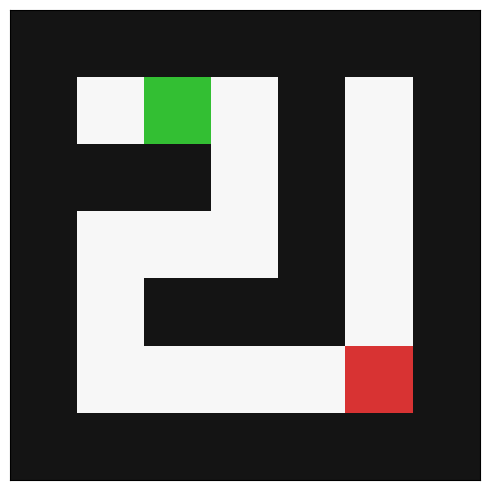

In [16]:
grid, start, goal = generate_one(3, 3, 1)
env = MazeEnv(grid, start, goal)

grid_t = torch.from_numpy(grid).float()
start_t = torch.tensor(start, dtype=torch.long)
goal_t = torch.tensor(goal, dtype=torch.long)
obs = build_obs(grid_t, start_t, goal_t)
policy_value = MLPPolicyValue(grid_t.shape[0], grid_t.shape[1])
logits, value = policy_value(obs.view(1, -1))

dist = torch.distributions.Categorical(logits=logits)
action = dist.sample()
next_state, reward, done = env.step(start, action)

plot_maze(grid, next_state, goal)

In [13]:
agent = PPO(policy_value_network=policy_value)

NameError: name 'policy_value' is not defined